# Credit Risk Intelligence Platform
## Notebook 2 — Feature Engineering + Borrower Segmentation



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.metrics         import silhouette_score
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('./outputs', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
})
ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'
BLUE   = '#56b4e9'

print("  Imports done")

  Imports done


In [2]:
df = pd.read_csv('./data/df_cleaned.csv')

print(f" Loaded: {df.shape}")
print(f"    Columns: {df.columns.tolist()}")
print(f"    Default rate: {df['loan_status'].mean()*100:.1f}%")

 Loaded: (31677, 18)
    Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'borrower_id', 'debt_to_income', 'loan_to_income', 'income_per_year', 'monthly_payment', 'rate_bucket']
    Default rate: 21.5%


## Feature Group 1 — Financial Stress Indicators


In [3]:
# ── Debt burden ratios ────────────────────────────────────────
df['debt_to_income']        = df['loan_amnt'] / (df['person_income'] + 1)
df['loan_to_income']        = df['loan_amnt'] / (df['person_income'] + 1)
df['income_per_emp_year']   = df['person_income'] / (df['person_emp_length'] + 1)

# ── Interest burden ───────────────────────────────────────────
df['annual_interest_cost']  = df['loan_amnt'] * (df['loan_int_rate'] / 100)
df['interest_to_income']    = df['annual_interest_cost'] / (df['person_income'] + 1)

# ── Loan size relative to credit history ─────────────────────
df['loan_per_credit_year']  = df['loan_amnt'] / (
    df['cb_person_cred_hist_length'] + 1)

# ── Payment stress proxy ──────────────────────────────────────
# Monthly payment estimate assuming 36-month term
df['est_monthly_payment']   = df['loan_amnt'] / 36
df['payment_to_income']     = (df['est_monthly_payment'] * 12) / (
    df['person_income'] + 1)

print("Financial stress features created:")
stress_cols = ['debt_to_income','interest_to_income',
               'payment_to_income','income_per_emp_year']
print(df.groupby('loan_status')[stress_cols].mean().round(4))
print("\n  Higher values = more stress = higher default rate")

Financial stress features created:
             debt_to_income  interest_to_income  payment_to_income  \
loan_status                                                          
0                    0.1484              0.0158             0.0495   
1                    0.2486              0.0317             0.0829   

             income_per_emp_year  
loan_status                       
0                     20258.0704  
1                     16698.6476  

  Higher values = more stress = higher default rate


## Feature Group 2 — Credit Risk Signals



In [4]:
# ── Grade risk encoding (ordinal — A is best, G is worst) ────
grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df['grade_risk_score'] = df['loan_grade'].map(grade_map)

# ── Prior default flag ────────────────────────────────────────
df['prior_default'] = (
    df['cb_person_default_on_file'] == 'Y').astype(int)

# ── Credit history strength ───────────────────────────────────
# Longer history = more established = lower risk
df['credit_hist_strength'] = np.log1p(
    df['cb_person_cred_hist_length'])

# ── Rate spread above grade average ──────────────────────────
# If someone's rate is higher than their grade average,
# the lender already sees them as riskier
grade_avg_rate = df.groupby('loan_grade')['loan_int_rate'].transform('mean')
df['rate_above_grade_avg'] = df['loan_int_rate'] - grade_avg_rate

# ── High interest flag ────────────────────────────────────────
df['high_interest_flag'] = (df['loan_int_rate'] > 15).astype(int)

print("Credit risk signal features created:")
credit_cols = ['grade_risk_score','prior_default',
               'rate_above_grade_avg','high_interest_flag']
print(df.groupby('loan_status')[credit_cols].mean().round(4))

Credit risk signal features created:
             grade_risk_score  prior_default  rate_above_grade_avg  \
loan_status                                                          
0                      1.9959         0.1414               -0.0101   
1                      3.0670         0.3097                0.0369   

             high_interest_flag  
loan_status                      
0                        0.0640  
1                        0.3201  


## Feature Group 3 — Borrower Stability Indicators



In [5]:
# ==========================
# Stability-based Features
# ==========================

import numpy as np
import pandas as pd

# ── Age-based stability ───────────────────────────────────────
# Younger applicants are generally considered higher risk due to
# limited credit history, while middle-aged applicants are more stable.

df['age_group_risk'] = pd.cut(
    df['person_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[5, 4, 3, 2, 1]
).astype(int)

# ── Employment stability ──────────────────────────────────────
# Log transform to reduce skewness in employment length.

df['emp_stability'] = np.log1p(df['person_emp_length'])

# Flag applicants with less than 2 years of employment.
df['short_emp_flag'] = (
    df['person_emp_length'] < 2
).astype(int)

# ── Home ownership risk ───────────────────────────────────────
# Lower value = more financially stable

ownership_map = {
    'OWN': 1,
    'MORTGAGE': 2,
    'RENT': 3,
    'OTHER': 4
}

df['home_ownership_risk'] = (
    df['person_home_ownership']
    .map(ownership_map)
    .fillna(3)
)

# ── Income stability ──────────────────────────────────────────
# Log transformation helps normalize highly skewed income values.

df['log_income'] = np.log1p(df['person_income'])

# Flag applicants in the lowest 25% income bracket.

df['low_income_flag'] = (
    df['person_income']
    < df['person_income'].quantile(0.25)
).astype(int)

# ── Summary ───────────────────────────────────────────────────

print(" Stability features created.\n")

stability_cols = [
    'age_group_risk',
    'emp_stability',
    'home_ownership_risk',
    'low_income_flag'
]

print(df.groupby('loan_status')[stability_cols].mean().round(4))

 Stability features created.

             age_group_risk  emp_stability  home_ownership_risk  \
loan_status                                                       
0                    4.3310         1.5248               2.3614   
1                    4.3707         1.3386               2.7171   

             low_income_flag  
loan_status                   
0                     0.1914  
1                     0.4633  


## Feature Group 4 — Loan Purpose Encoding

Different loan intents carry very different risk profiles.
Medical and debt consolidation loans are taken under stress —
education and home improvement are more planned.

In [6]:
# ── Intent risk mapping (based on EDA from notebook 1) ───────
intent_risk = df.groupby('loan_intent')['loan_status'].mean()
print("Default rate by intent (use this to set risk scores):")
print(intent_risk.sort_values(ascending=False).round(3))

# Map intent to its actual default rate (target encoding)
df['intent_default_rate'] = df['loan_intent'].map(intent_risk)

# ── One-hot encode loan intent ────────────────────────────────
intent_dummies = pd.get_dummies(
    df['loan_intent'], prefix='intent', drop_first=True)
df = pd.concat([df, intent_dummies], axis=1)

print(f"\n  Intent features created: {intent_dummies.columns.tolist()}")

Default rate by intent (use this to set risk scores):
loan_intent
DEBTCONSOLIDATION    0.284
MEDICAL              0.265
HOMEIMPROVEMENT      0.256
PERSONAL             0.195
EDUCATION            0.170
VENTURE              0.147
Name: loan_status, dtype: float64

  Intent features created: ['intent_EDUCATION', 'intent_HOMEIMPROVEMENT', 'intent_MEDICAL', 'intent_PERSONAL', 'intent_VENTURE']


## Final Feature Matrix



In [7]:
FEATURE_COLS = [
    # Group 1 — Financial stress
    'debt_to_income', 'interest_to_income',
    'payment_to_income', 'income_per_emp_year',
    'annual_interest_cost', 'loan_per_credit_year',
    # Group 2 — Credit risk
    'grade_risk_score', 'prior_default',
    'credit_hist_strength', 'rate_above_grade_avg',
    'high_interest_flag', 'loan_percent_income',
    # Group 3 — Stability
    'age_group_risk', 'emp_stability', 'short_emp_flag',
    'home_ownership_risk', 'log_income', 'low_income_flag',
    # Group 4 — Loan purpose
    'intent_default_rate',
    # Raw numerics (keep for clustering)
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate',
    'cb_person_cred_hist_length',
]

# Add intent dummies
intent_cols = [c for c in df.columns if c.startswith('intent_')]
FEATURE_COLS += intent_cols

# Keep only columns that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].fillna(0).values
y = df['loan_status'].values

print(f" Feature matrix: {X.shape}")
print(f"    Features: {len(FEATURE_COLS)}")
print(f"    Target: {y.sum():,} defaults out of {len(y):,} borrowers")
print(f"\nFeature list:")
for i, f in enumerate(FEATURE_COLS):
    print(f"    {i+1:02d}. {f}")

 Feature matrix: (31677, 31)
    Features: 31
    Target: 6,825 defaults out of 31,677 borrowers

Feature list:
    01. debt_to_income
    02. interest_to_income
    03. payment_to_income
    04. income_per_emp_year
    05. annual_interest_cost
    06. loan_per_credit_year
    07. grade_risk_score
    08. prior_default
    09. credit_hist_strength
    10. rate_above_grade_avg
    11. high_interest_flag
    12. loan_percent_income
    13. age_group_risk
    14. emp_stability
    15. short_emp_flag
    16. home_ownership_risk
    17. log_income
    18. low_income_flag
    19. intent_default_rate
    20. person_age
    21. person_income
    22. person_emp_length
    23. loan_amnt
    24. loan_int_rate
    25. cb_person_cred_hist_length
    26. intent_default_rate
    27. intent_EDUCATION
    28. intent_HOMEIMPROVEMENT
    29. intent_MEDICAL
    30. intent_PERSONAL
    31. intent_VENTURE


## Borrower Persona Clustering (Layer 3)

**Why cluster before modelling?**

A single model treats all borrowers the same.
But a 22-year-old student borrowing for education
is fundamentally different from a 45-year-old
taking a debt consolidation loan.

KMeans groups borrowers into personas based on their
financial profile — BEFORE we look at who defaulted.
Then we see how default rates vary across personas.

**Finding the right number of clusters:**
We use the Elbow method + Silhouette score together.

In [8]:
# Scale features for clustering
scaler_cluster = StandardScaler()

# Use a subset of meaningful features for clustering
CLUSTER_FEATURES = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'debt_to_income',
    'grade_risk_score', 'prior_default',
    'credit_hist_strength', 'home_ownership_risk',
    'payment_to_income', 'loan_percent_income'
]
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in df.columns]

X_cluster = scaler_cluster.fit_transform(
    df[CLUSTER_FEATURES].fillna(0))

# Test k from 2 to 8
inertias    = []
silhouettes = []
K_range     = range(2, 9)

print("Finding optimal k...")
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42,
                 n_init=10, max_iter=300)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(
        X_cluster, labels, sample_size=5000,
        random_state=42))
    print(f"   k={k}  inertia={km.inertia_:.0f}  "
          f"silhouette={silhouettes[-1]:.4f}")

print(f"\n📌  Best silhouette at k="
      f"{K_range[np.argmax(silhouettes)]}")

Finding optimal k...
   k=2  inertia=303902  silhouette=0.2140
   k=3  inertia=263165  silhouette=0.2080
   k=4  inertia=236976  silhouette=0.1769
   k=5  inertia=222995  silhouette=0.1380
   k=6  inertia=211392  silhouette=0.1443
   k=7  inertia=200726  silhouette=0.1403
   k=8  inertia=191408  silhouette=0.1438

📌  Best silhouette at k=2


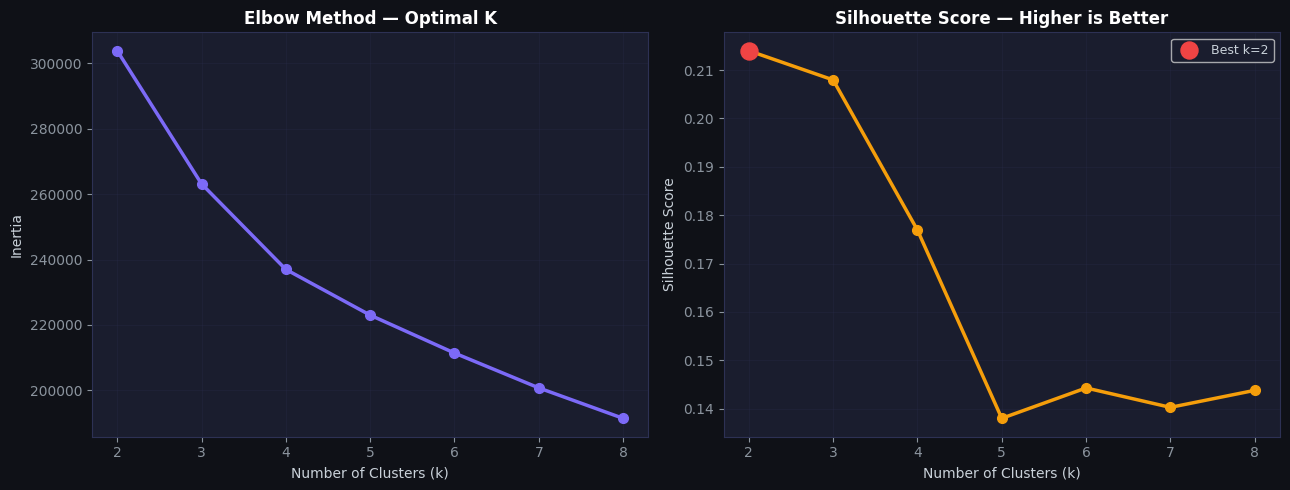

 Saved: ./outputs/cluster_selection.png

  Use k=2 in next cell


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(alpha=0.3)

# Elbow
ax1.plot(list(K_range), inertias,
         color=ACCENT, linewidth=2.5,
         marker='o', markersize=7)
ax1.set_title('Elbow Method — Optimal K',
              fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Number of Clusters (k)', fontsize=10)
ax1.set_ylabel('Inertia', fontsize=10)

# Silhouette
best_k_idx = np.argmax(silhouettes)
ax2.plot(list(K_range), silhouettes,
         color=YELLOW, linewidth=2.5,
         marker='o', markersize=7)
ax2.scatter(list(K_range)[best_k_idx],
            silhouettes[best_k_idx],
            color=RED, s=150, zorder=5,
            label=f'Best k={list(K_range)[best_k_idx]}')
ax2.set_title('Silhouette Score — Higher is Better',
              fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel('Number of Clusters (k)', fontsize=10)
ax2.set_ylabel('Silhouette Score', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/cluster_selection.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" Saved: ./outputs/cluster_selection.png")
print(f"\n  Use k={list(K_range)[best_k_idx]} in next cell")

In [10]:
# Use best k from silhouette (usually 4 or 5)
# Change this number if your plot suggests different
BEST_K = list(K_range)[np.argmax(silhouettes)]
print(f"Using k = {BEST_K}")

km_final = KMeans(n_clusters=BEST_K, random_state=42,
                  n_init=10, max_iter=300)
df['cluster'] = km_final.fit_predict(X_cluster)

# Profile each cluster
cluster_profile = df.groupby('cluster').agg(
    count           = ('loan_status',             'count'),
    default_rate    = ('loan_status',             'mean'),
    avg_age         = ('person_age',              'mean'),
    avg_income      = ('person_income',           'mean'),
    avg_loan        = ('loan_amnt',               'mean'),
    avg_int_rate    = ('loan_int_rate',           'mean'),
    avg_emp_length  = ('person_emp_length',       'mean'),
    pct_prior_def   = ('prior_default',           'mean'),
    avg_grade_risk  = ('grade_risk_score',        'mean'),
).round(2)

cluster_profile['default_rate_pct'] = (
    cluster_profile['default_rate'] * 100).round(1)

print("\nCluster Profiles:")
print(cluster_profile.to_string())
print("\n  Name each cluster based on its profile")
print("    High default rate + young age = 'At-Risk Young Borrower'")
print("    Low default rate + high income = 'Stable Prime Borrower'")
print("    etc.")

Using k = 2

Cluster Profiles:
         count  default_rate  avg_age  avg_income  avg_loan  avg_int_rate  avg_emp_length  pct_prior_def  avg_grade_risk  default_rate_pct
cluster                                                                                                                                   
0        20887          0.12    27.91    73653.73   7268.70         10.44            4.95           0.14            2.00              12.0
1        10790          0.41    27.37    52624.25  14289.16         12.21            4.45           0.25            2.66              41.0

  Name each cluster based on its profile
    High default rate + young age = 'At-Risk Young Borrower'
    Low default rate + high income = 'Stable Prime Borrower'
    etc.


In [11]:
# After reviewing cluster_profile above,
# assign human-readable persona names
# These are typical — adjust based on YOUR cluster output

def assign_persona(row):
    dr  = row['default_rate']
    inc = row['avg_income']
    age = row['avg_age']
    gr  = row['avg_grade_risk']

    if dr > 0.35:
        if age < 30:
            return 'At-Risk Young Borrower'
        else:
            return 'Overextended Borrower'
    elif dr > 0.20:
        if gr > 4:
            return 'Subprime Stressed Borrower'
        else:
            return 'Mid-Risk Consolidator'
    elif inc > 80000:
        return 'Stable Prime Borrower'
    else:
        return 'Cautious Low-Income Borrower'

cluster_profile['persona'] = cluster_profile.apply(
    assign_persona, axis=1)
print("Persona assignments:")
print(cluster_profile[['count','default_rate_pct','persona']])

# Map persona back to main dataframe
persona_map = cluster_profile['persona'].to_dict()
df['persona'] = df['cluster'].map(persona_map)
print(f"\n Personas assigned")
print(df['persona'].value_counts())

Persona assignments:
         count  default_rate_pct                       persona
cluster                                                       
0        20887              12.0  Cautious Low-Income Borrower
1        10790              41.0        At-Risk Young Borrower

 Personas assigned
persona
Cautious Low-Income Borrower    20887
At-Risk Young Borrower          10790
Name: count, dtype: int64


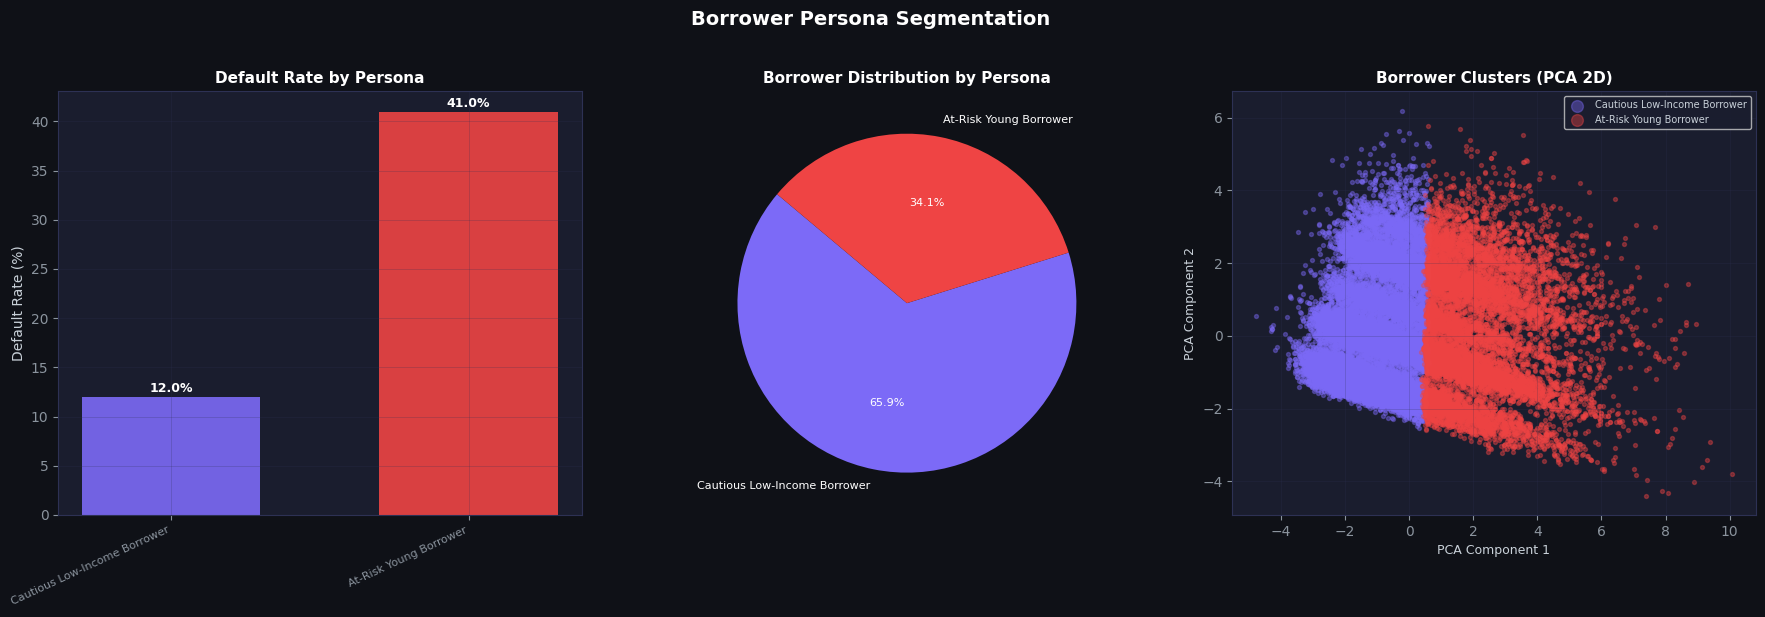

  Saved: ./outputs/borrower_personas.png


In [12]:
PERSONA_COLORS = [ACCENT, RED, GREEN, YELLOW, BLUE,
                  '#f97316', '#a855f7'][:BEST_K]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d2e')
    ax.grid(alpha=0.3)

personas   = cluster_profile['persona'].values
def_rates  = cluster_profile['default_rate_pct'].values
counts     = cluster_profile['count'].values

# ── Plot 1: Default rate per persona ─────────────────────────
bars = axes[0].bar(range(len(personas)), def_rates,
                   color=PERSONA_COLORS, alpha=0.9, width=0.6)
for bar, val in zip(bars, def_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center',
                 fontsize=9, color='white', fontweight='bold')
axes[0].set_xticks(range(len(personas)))
axes[0].set_xticklabels(personas, rotation=25,
                         ha='right', fontsize=8)
axes[0].set_title('Default Rate by Persona',
                  fontsize=11, fontweight='bold', color='white')
axes[0].set_ylabel('Default Rate (%)')

# ── Plot 2: Persona size ──────────────────────────────────────
axes[1].pie(counts, labels=personas,
            colors=PERSONA_COLORS,
            autopct='%1.1f%%',
            textprops={'color':'white', 'fontsize':8},
            startangle=140)
axes[1].set_title('Borrower Distribution by Persona',
                  fontsize=11, fontweight='bold', color='white')

# ── Plot 3: PCA scatter of clusters ──────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

for i, (persona, color) in enumerate(
        zip(personas, PERSONA_COLORS)):
    mask = df['cluster'] == i
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=persona,
                    alpha=0.4, s=8)

axes[2].set_title('Borrower Clusters (PCA 2D)',
                  fontsize=11, fontweight='bold', color='white')
axes[2].set_xlabel('PCA Component 1', fontsize=9)
axes[2].set_ylabel('PCA Component 2', fontsize=9)
axes[2].legend(fontsize=7, markerscale=3)

fig.suptitle('Borrower Persona Segmentation',
             fontsize=14, fontweight='bold',
             color='white', y=1.02)

plt.tight_layout()
plt.savefig('./outputs/borrower_personas.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/borrower_personas.png")

In [13]:
import joblib

# Save feature matrix
np.savez('./data/features.npz', X=X, y=y)

# Save feature names
np.save('./data/feature_names.npy',
        np.array(FEATURE_COLS, dtype=object))

# Save cluster model + scaler
joblib.dump(km_final,       './outputs/kmeans_model.pkl')
joblib.dump(scaler_cluster, './outputs/cluster_scaler.pkl')
np.save('./data/cluster_features.npy',
        np.array(CLUSTER_FEATURES, dtype=object))

# Save full featured dataframe
df.to_csv('./data/df_featured.csv', index=False)

# Save cluster profiles for Power BI
cluster_profile.reset_index().to_csv(
    './outputs/powerbi_personas.csv', index=False)

print("  Saved:")
print("    ./data/features.npz")
print("    ./data/feature_names.npy")
print("    ./data/df_featured.csv")
print("    ./outputs/kmeans_model.pkl")
print("    ./outputs/cluster_scaler.pkl")
print("    ./outputs/powerbi_personas.csv")
print(f"\n  Summary for resume:")
print(f"    Total features engineered: {len(FEATURE_COLS)}")
print(f"    Borrower personas found:   {BEST_K}")
print(f"    Personas: {list(personas)}")

  Saved:
    ./data/features.npz
    ./data/feature_names.npy
    ./data/df_featured.csv
    ./outputs/kmeans_model.pkl
    ./outputs/cluster_scaler.pkl
    ./outputs/powerbi_personas.csv

  Summary for resume:
    Total features engineered: 31
    Borrower personas found:   2
    Personas: ['Cautious Low-Income Borrower', 'At-Risk Young Borrower']
